In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
OUT = "."

In [3]:
df = sns.load_dataset("titanic")   # <-- the ONE and ONLY raw load
print("shape:", df.shape)
df.info()
df.describe()

shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
miss = (df.isnull().sum() / len(df) * 100)
miss = miss[miss > 0].sort_values(ascending=False)
print("Missing % per column:\n", miss.round(2))

Missing % per column:
 deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64


In [5]:
df.to_csv("titanic.csv", index=False)
print("saved titanic.csv")

saved titanic.csv


In [6]:
# Rule: <5% -> drop rows | 5-30% -> impute | >30% -> drop col or encode "missing"
# deck      77.22%  -> drop column (imputation unreliable, redundant with pclass/embarked)
# age       19.87%  -> impute with median (robust to skew)
# embarked   0.22%  -> drop rows
# embark_town 0.22% -> drop rows

df = df.drop(columns=["deck"])
df["age"] = df["age"].fillna(df["age"].median())
df = df.dropna(subset=["embarked", "embark_town"])
print("remaining missing cells:", int(df.isnull().sum().sum()))

remaining missing cells: 0


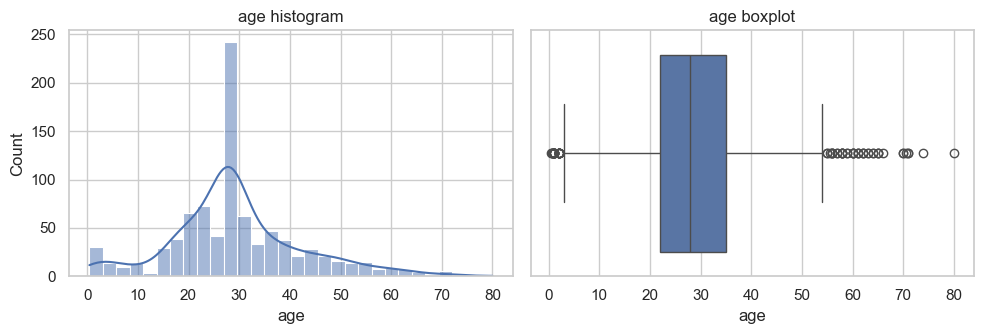

age: 65 IQR outliers  (bounds [2.50, 54.50])


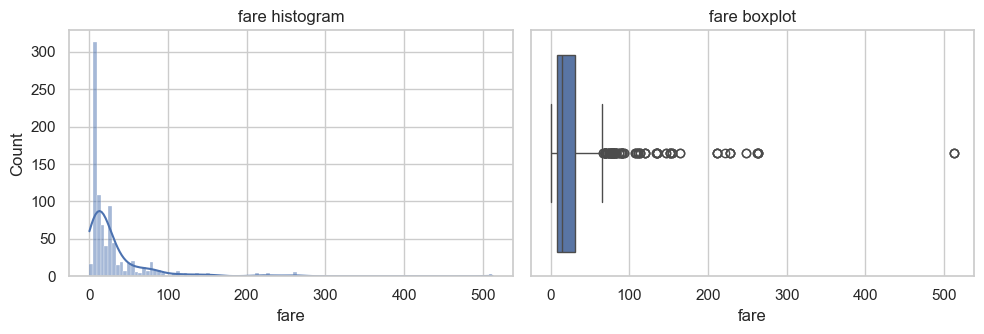

fare: 114 IQR outliers  (bounds [-26.76, 65.66])


In [7]:
def iqr_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((s < lo) | (s > hi)).sum()), lo, hi

for col in ["age", "fare"]:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    sns.histplot(df[col], kde=True, ax=ax[0]); ax[0].set_title(f"{col} histogram")
    sns.boxplot(x=df[col], ax=ax[1]); ax[1].set_title(f"{col} boxplot")
    fig.tight_layout(); fig.savefig(f"uni_{col}.png"); plt.show()
    n, lo, hi = iqr_outliers(df[col])
    print(f"{col}: {n} IQR outliers  (bounds [{lo:.2f}, {hi:.2f}])")

In [8]:
fare = df["fare"]
print(f"mean={fare.mean():.2f}  median={fare.median():.2f}  mode={fare.mode().iloc[0]:.2f}")
print("fare is RIGHT-SKEWED (mean > median > mode)")

mean=32.10  median=14.45  mode=8.05
fare is RIGHT-SKEWED (mean > median > mode)


In [9]:
df.groupby("sex")["survived"].mean().round(3)

sex
female    0.740
male      0.189
Name: survived, dtype: float64

In [10]:
df.groupby("pclass")["survived"].mean().round(3)

pclass
1    0.626
2    0.473
3    0.242
Name: survived, dtype: float64

In [11]:
print(df.groupby(["sex", "pclass"])["survived"].mean().round(3))
print("\nfemale & 1st:", round(df[(df.sex=="female") & (df.pclass==1)]["survived"].mean(), 3))
print("male   & 3rd:", round(df[(df.sex=="male")   & (df.pclass==3)]["survived"].mean(), 3))

sex     pclass
female  1         0.967
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: survived, dtype: float64

female & 1st: 0.967
male   & 3rd: 0.135


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


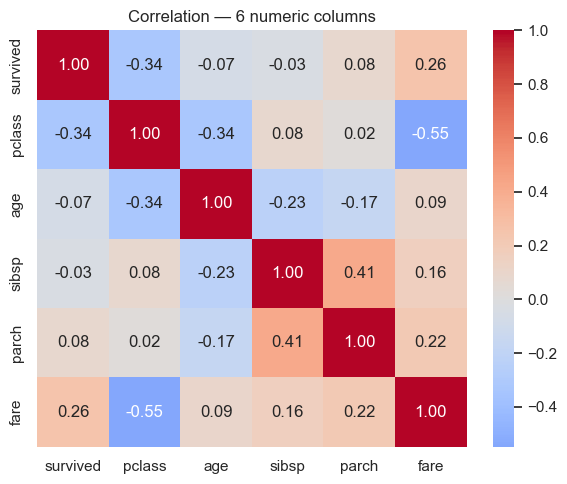

In [12]:
cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[cols].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — 6 numeric columns")
fig.tight_layout(); fig.savefig("corr.png"); plt.show()

In [13]:
pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(cols) for b in cols[i+1:]]
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("Top 2 |corr| pairs:")
for a, b, r in pairs[:2]:
    print(f"  {a} vs {b}: r = {r:.3f}")

Top 2 |corr| pairs:
  pclass vs fare: r = -0.548
  sibsp vs parch: r = 0.415


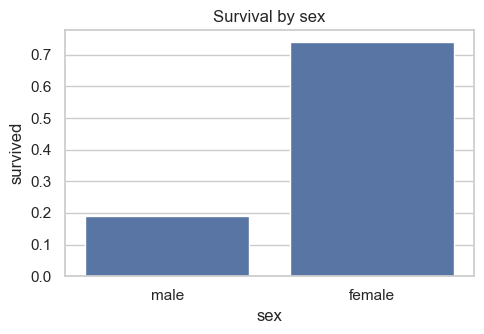

In [14]:
# 1. Survival by sex
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(data=df, x="sex", y="survived", ax=ax, errorbar=None)
ax.set_title("Survival by sex"); fig.tight_layout()
fig.savefig("story_sex.png"); plt.show()

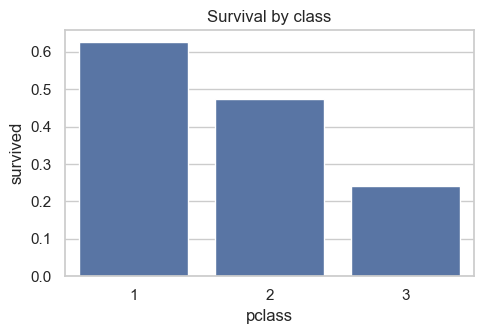

In [15]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(data=df, x="pclass", y="survived", ax=ax, errorbar=None)
ax.set_title("Survival by class"); fig.tight_layout()
fig.savefig("story_pclass.png"); plt.show()

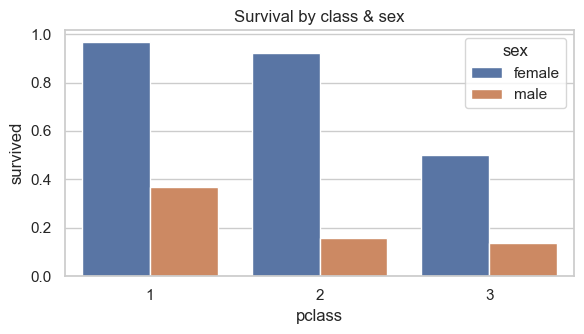

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=ax, errorbar=None)
ax.set_title("Survival by class & sex"); fig.tight_layout()
fig.savefig("story_sex_pclass.png"); plt.show()

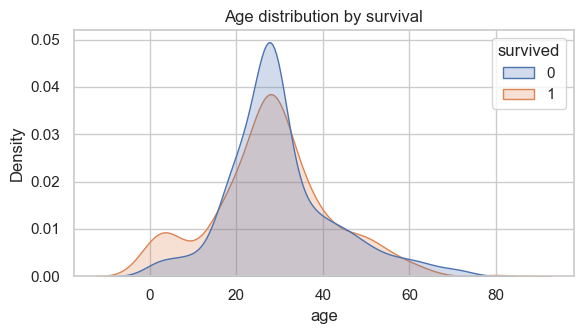

In [17]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.kdeplot(data=df, x="age", hue="survived", fill=True, ax=ax, common_norm=False)
ax.set_title("Age distribution by survival"); fig.tight_layout()
fig.savefig("story_age.png"); plt.show()

In [18]:
for col in ["age", "fare"]:
    m, s = df[col].mean(), df[col].std()
    z = (df[col] - m) / s
    print(f"{col}: before mean={m:.3f} std={s:.3f}  |  after mean={z.mean():.2e} std={z.std():.3f}")

age: before mean=29.315 std=12.985  |  after mean=2.84e-16 std=1.000
fare: before mean=32.097 std=49.698  |  after mean=1.32e-16 std=1.000


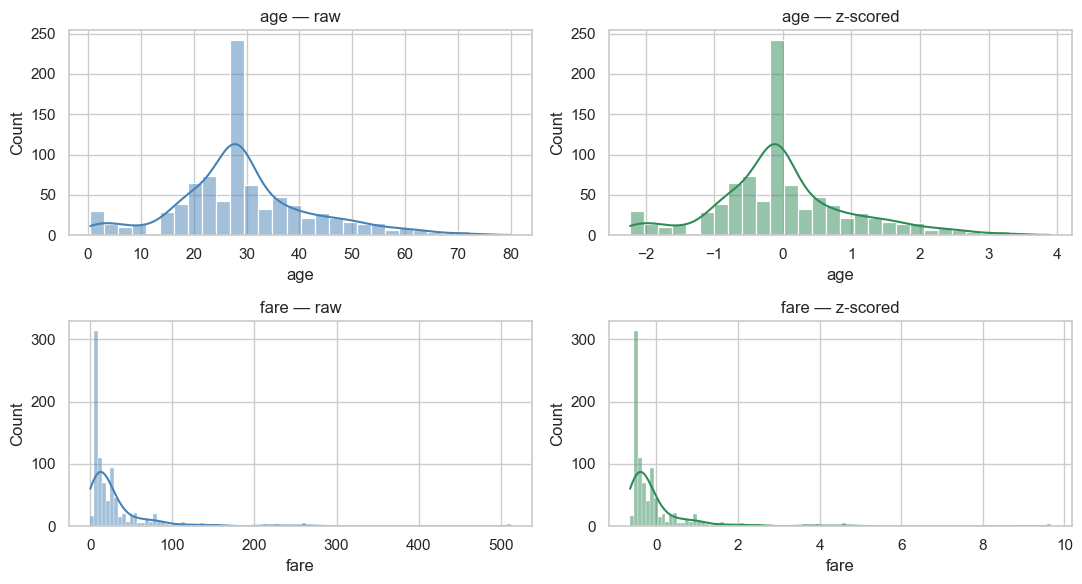

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for i, col in enumerate(["age", "fare"]):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"{col} — raw")
    z = (df[col] - df[col].mean()) / df[col].std()
    sns.histplot(z, kde=True, ax=axes[i, 1], color="seagreen")
    axes[i, 1].set_title(f"{col} — z-scored")
fig.tight_layout(); fig.savefig("standardization_check.png"); plt.show()